# Workforce Analytics: Understanding and Predicting Employee Turnover

`Installing Kaggle`

In [247]:
pip install kagglehub 

Note: you may need to restart the kernel to use updated packages.


`Importing Data from Kaggle`

In [248]:
import kagglehub

path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\senpr\.cache\kagglehub\datasets\pavansubhasht\ibm-hr-analytics-attrition-dataset\versions\1


In [249]:
import numpy as np
import pandas as pd 
import os

In [250]:
# Getting folder path
folder_path = path
print(os.listdir(folder_path))

['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [251]:
#reading data

df = pd.read_csv(
    os.path.join(folder_path, "WA_Fn-UseC_-HR-Employee-Attrition.csv")
) 

In [252]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [253]:
#shape
df.shape

(1470, 35)

In [254]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [255]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [256]:
df.rename(columns={"EmployeeNumber":"Emp_ID"}, inplace=True)

In [257]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   Emp_ID                    1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Missing values Check

In [258]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
Emp_ID                      0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Dupilcate check

In [259]:
df.duplicated().sum()

np.int64(0)

# New drived tables

#### Employee_demographic 

In [260]:
employees_demographic = df[["Emp_ID",
                            "Age", 
                            "Department", 
                            "EducationField",
                            "Gender",
                            "MaritalStatus",
                           ]]

In [261]:
employees_demographic

,Emp_ID,Age,Department,EducationField,Gender,MaritalStatus
0,1,41,Sales,Life Sciences,Female,Single
1,2,49,Research & Development,Life Sciences,Male,Married
2,4,37,Research & Development,Other,Male,Single
3,5,33,Research & Development,Life Sciences,Female,Married
4,7,27,Research & Development,Medical,Male,Married
...,...,...,...,...,...,...
1465,2061,36,Research & Development,Medical,Male,Married
1466,2062,39,Research & Development,Medical,Male,Married
1467,2064,27,Research & Development,Life Sciences,Male,Married
1468,2065,49,Sales,Medical,Male,Married


### Employee job

In [262]:
employee_job = df[[
    "Emp_ID",
    "Department",
    "JobRole",
    "JobLevel",
    "JobInvolvement"  
]]

In [263]:
employee_job

,Emp_ID,Department,JobRole,JobLevel,JobInvolvement
0,1,Sales,Sales Executive,2,3
1,2,Research & Development,Research Scientist,2,2
2,4,Research & Development,Laboratory Technician,1,2
3,5,Research & Development,Research Scientist,1,3
4,7,Research & Development,Laboratory Technician,1,3
...,...,...,...,...,...
1465,2061,Research & Development,Laboratory Technician,2,4
1466,2062,Research & Development,Healthcare Representative,3,2
1467,2064,Research & Development,Manufacturing Director,2,4
1468,2065,Sales,Sales Executive,2,2


### Employee performance

In [264]:
employee_performance = df[[
    "Emp_ID",
    "PerformanceRating",
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance"
]]

In [265]:
employee_performance

,Emp_ID,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance
0,1,3,2,4,1,1
1,2,4,3,2,4,3
2,4,3,4,3,2,3
3,5,3,4,3,3,3
4,7,3,1,2,4,3
...,...,...,...,...,...,...
1465,2061,3,3,4,3,3
1466,2062,3,4,1,1,3
1467,2064,4,2,2,2,3
1468,2065,3,4,2,4,2


### Employee salary

In [266]:
employee_salary = df[[
    "Emp_ID",
    "MonthlyIncome",
    "HourlyRate",
    "PercentSalaryHike",
    "StockOptionLevel"
]]

In [267]:
employee_salary

,Emp_ID,MonthlyIncome,HourlyRate,PercentSalaryHike,StockOptionLevel
0,1,5993,94,11,0
1,2,5130,61,23,1
2,4,2090,92,15,0
3,5,2909,56,11,0
4,7,3468,40,12,1
...,...,...,...,...,...
1465,2061,2571,41,17,1
1466,2062,9991,42,15,1
1467,2064,6142,87,20,1
1468,2065,5390,63,14,0


### Employee experience

In [268]:
employee_experience = df[[
    "Emp_ID",
    "NumCompaniesWorked",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "TrainingTimesLastYear"
]]

In [269]:
employee_experience

,Emp_ID,NumCompaniesWorked,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TrainingTimesLastYear
0,1,8,8,6,4,0,5,0
1,2,1,10,10,7,1,7,3
2,4,6,7,0,0,0,0,3
3,5,1,8,8,7,3,0,3
4,7,9,6,2,2,2,2,3
...,...,...,...,...,...,...,...,...
1465,2061,4,17,5,2,0,3,3
1466,2062,4,9,7,7,1,7,5
1467,2064,1,6,6,2,0,3,0
1468,2065,2,17,9,6,0,8,3


### Employee attrition

In [270]:
employee_attrition = df[[
    "Emp_ID",
    "Attrition",
    "OverTime",
    "BusinessTravel"
]]

In [271]:
employee_attrition

,Emp_ID,Attrition,OverTime,BusinessTravel
0,1,Yes,Yes,Travel_Rarely
1,2,No,No,Travel_Frequently
2,4,Yes,Yes,Travel_Rarely
3,5,No,Yes,Travel_Frequently
4,7,No,No,Travel_Rarely
...,...,...,...,...
1465,2061,No,No,Travel_Frequently
1466,2062,No,No,Travel_Rarely
1467,2064,No,Yes,Travel_Rarely
1468,2065,No,No,Travel_Frequently


# OverTime Distribution

### Questions Explored During OverTime Analysis
1. What percentage of employees are working overtime?
2. Which job roles have the highest overtime participation?
3. Are research-focused and sales-oriented roles more involved in overtime work?
4. Does workforce size influence overtime percentage interpretation?

In [272]:
employee_attrition["OverTime"].value_counts()

OverTime
No     1054
Yes     416
Name: count, dtype: int64

In [273]:
employee_attrition["OverTime"].value_counts(normalize = True) * 100

OverTime
No     71.70068
Yes    28.29932
Name: proportion, dtype: float64

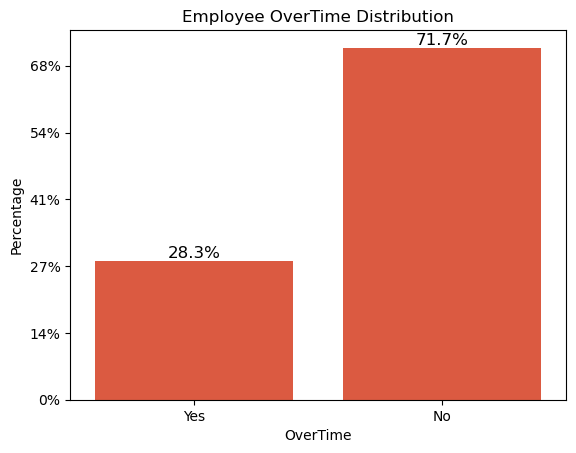

In [274]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

ax = sns.countplot(
    x="OverTime",
    data=employee_attrition,
    color="#F54927"
)

total = len(employee_attrition)

for p in ax.patches:
    
    percentage = 100 * p.get_height() / total
    
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    
    ax.annotate(
        f'{percentage:.1f}%',
        (x, y),
        ha='center',
        va='bottom',
        fontsize=12
    )
ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=total)
)

plt.title("Employee OverTime Distribution")
plt.ylabel("Percentage")
plt.show()

# Overtime analysis 
We can see that only 28% of employees are working over time that is 416 out of 1470

# Job roles that are working over time

In [275]:
over_time = pd.merge(employee_job,employee_attrition, on = "Emp_ID", how = "inner")
over_time_fil = over_time[over_time["OverTime"]== "Yes"]
ot = over_time_fil.groupby("JobRole")["OverTime"].count().reset_index()

`OverTime_x = overtime employees
OverTime_y = total employees`

In [276]:
ot.sort_values(by ="OverTime", ascending = False)

,JobRole,OverTime
6,Research Scientist,97
7,Sales Executive,94
2,Laboratory Technician,62
4,Manufacturing Director,39
0,Healthcare Representative,37
3,Manager,27
8,Sales Representative,24
5,Research Director,23
1,Human Resources,13


### Overtime count Visual

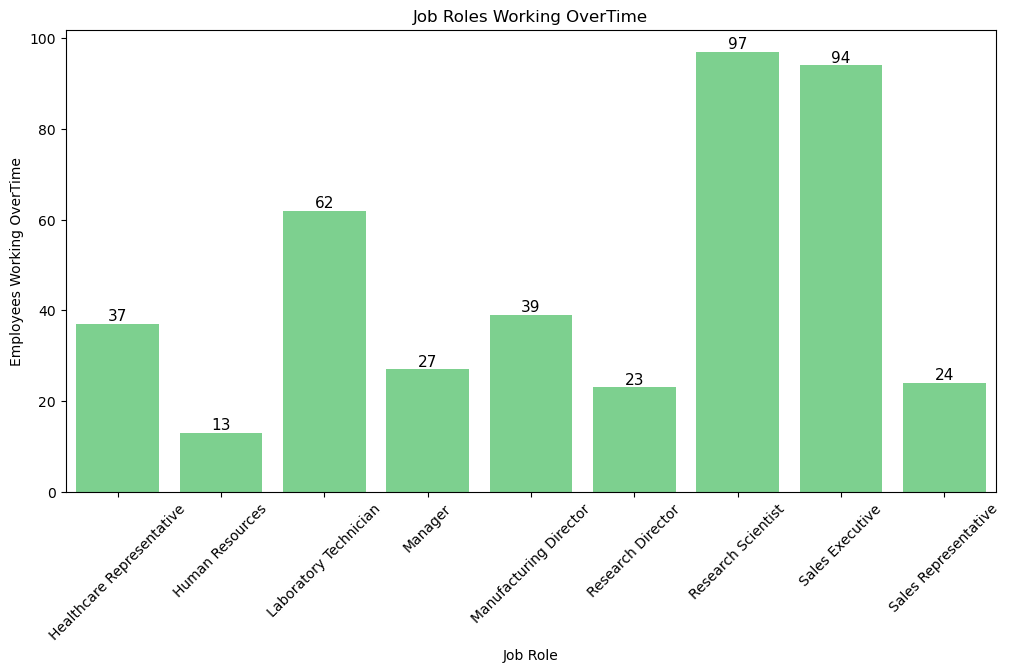

In [277]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x="JobRole",
    y="OverTime",
    data=ot,
    color= "#6FDE87"
)

# Add labels on bars
for p in ax.patches:
    
    height = p.get_height()
    
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.xticks(rotation=45)

plt.title("Job Roles Working OverTime")
plt.xlabel("Job Role")
plt.ylabel("Employees Working OverTime")

plt.show()

In [278]:
#Total employees 
total = over_time.groupby("JobRole")["OverTime"].count().reset_index()
# Merge
comparison = pd.merge(ot,total, on="JobRole")
comparison["OverTime_Percentage"] = (
    comparison["OverTime_x"] /
    comparison["OverTime_y"]
).round(2) * 100 
comparison

,JobRole,OverTime_x,OverTime_y,OverTime_Percentage
0,Healthcare Representative,37,131,28.0
1,Human Resources,13,52,25.0
2,Laboratory Technician,62,259,24.0
3,Manager,27,102,26.0
4,Manufacturing Director,39,145,27.0
5,Research Director,23,80,29.0
6,Research Scientist,97,292,33.0
7,Sales Executive,94,326,29.0
8,Sales Representative,24,83,29.0


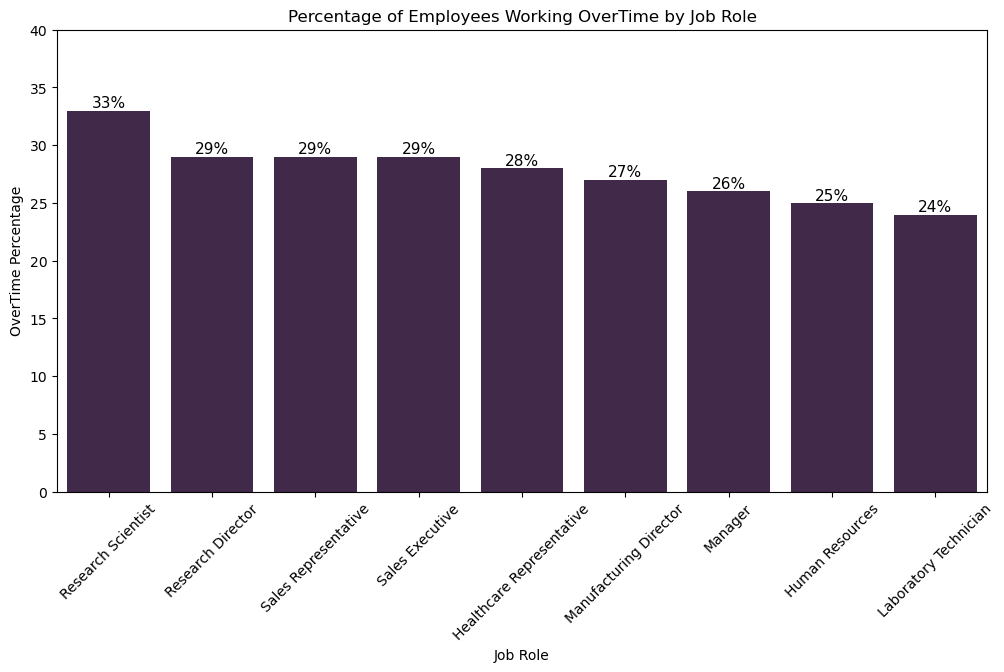

In [279]:
# Sort values
comparison = comparison.sort_values(
    by="OverTime_Percentage",
    ascending=False
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x="JobRole",
    y="OverTime_Percentage",
    data=comparison,
    color="#44244F"
)

# Add percentage labels
for p in ax.patches:
    
    height = p.get_height()
    
    ax.annotate(
        f'{height:.0f}%',
        (p.get_x() + p.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.xticks(rotation=45)

plt.title("Percentage of Employees Working OverTime by Job Role")
plt.xlabel("Job Role")
plt.ylabel("OverTime Percentage")

plt.ylim(0,40)

plt.show()

# OverTime Analysis

## Objective
The purpose of this analysis is to understand overtime participation among employees and identify which job roles are more involved in overtime work.

Since the primary objective of the project is employee attrition analysis, overtime is being explored as a potential factor influencing employee retention.

---

# 1. Overall OverTime Participation

## Observation
The analysis revealed that approximately:

- **28.3%** employees are working overtime
- **71.7%** employees are not involved in overtime work

This indicates that a considerable portion of the workforce regularly works beyond standard working hours.

---

# Key Business Insight

A notable percentage of employees are involved in overtime work, which may indicate:

- workload pressure,
- operational demand,
- resource imbalance,
- or target-driven work culture.

Excessive overtime may potentially impact:

- employee satisfaction,
- work-life balance,
- stress levels,
- and employee retention.
---

# Job Role Insights
## Research Scientists show the highest overtime participation
- Approximately **33%** of Research Scientists are working overtime.
- This is the highest overtime percentage among all job roles.
- The finding may indicate high project workload, deadlines, or research pressure.
---
## Sales-oriented roles also demonstrate high overtime involvement
- Sales Executive: **29%**
- Sales Representative: **29%**

This may suggest that:
- sales targets,
- client management,
- and performance expectations  
contribute to extended working hours.
---

## Human Resources and Laboratory Technicians show relatively lower overtime percentages
- Human Resources: **25%**
- Laboratory Technicians: **24%**
These roles may have comparatively structured workflows and operational schedules.
---

# Important Analytical Observation
## Workforce size can influence percentage interpretation
Some job roles have a smaller employee population, which may affect overtime percentages.

For example:
- Human Resources has only **52 employees**
- Research Director has only **80 employees**

In smaller groups:
- even a small increase in overtime employees
- can significantly impact the overall percentage.

---

# Combined Business Insight

The analysis suggests that overtime participation is not equally distributed across job roles.

Research-focused and sales-oriented roles appear to experience comparatively higher overtime involvement, which may indicate:

- workload imbalance,
- operational pressure,
- and extended working hours.

`At this stage, overtime is being considered as a potential factor that may influence employee attrition and work-life balance.`

Further analysis will explore whether employees working overtime are more likely to leave the organization.

---
# Business Questions for Further Analysis

## Question 1
> Are employees working overtime more likely to leave the organization?
## Question 2
> Do job roles with higher overtime participation also experience higher attrition?
## Question 3
> Does overtime negatively impact employee work-life balance and satisfaction?

---

# Hypotheses for Future Testing

## Hypothesis 1
### Null Hypothesis (H₀)
> OverTime has no significant relationship with employee attrition.

### Alternate Hypothesis (H₁)
> Employees working overtime are more likely to leave the organization.

---

## Hypothesis 2

### Null Hypothesis (H₀)
> Job roles and overtime participation are independent.

### Alternate Hypothesis (H₁)
> Certain job roles experience significantly higher overtime participation.

---

## Hypothesis 3
### Null Hypothesis (H₀)
> Work-life balance is not affected by overtime participation.

### Alternate Hypothesis (H₁)
> Employees working overtime experience lower work-life balance.

# Compensation Analysis
### Questions Explored During Salary Analysis

1. Which job roles receive the highest average monthly income?
2. Do high-salary job roles also experience high overtime participation?
3. How does salary distribution vary across different job roles?
4. Are managerial and research-focused roles compensated higher than operational roles?
5. Which job roles receive comparatively lower compensation despite workload involvement?
6. Does compensation appear aligned with role responsibility and hierarchy?

In [280]:
employee_salary

,Emp_ID,MonthlyIncome,HourlyRate,PercentSalaryHike,StockOptionLevel
0,1,5993,94,11,0
1,2,5130,61,23,1
2,4,2090,92,15,0
3,5,2909,56,11,0
4,7,3468,40,12,1
...,...,...,...,...,...
1465,2061,2571,41,17,1
1466,2062,9991,42,15,1
1467,2064,6142,87,20,1
1468,2065,5390,63,14,0


In [281]:
employee_salary.describe()

,Emp_ID,MonthlyIncome,HourlyRate,PercentSalaryHike,StockOptionLevel
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,1024.865306,6502.931293,65.891156,15.209524,0.793878
std,602.024335,4707.956783,20.329428,3.659938,0.852077
min,1.000000,1009.000000,30.000000,11.000000,0.000000
25%,491.250000,2911.000000,48.000000,12.000000,0.000000
50%,1020.500000,4919.000000,66.000000,14.000000,1.000000
75%,1555.750000,8379.000000,83.750000,18.000000,1.000000
max,2068.000000,19999.000000,100.000000,25.000000,3.000000


### `Highest average monthly income`

In [282]:
salary_merge = pd.merge(employee_job, employee_salary, on = "Emp_ID", how = "inner")  # Merging tables
salary_grp_job_role = salary_merge.groupby("JobRole")['MonthlyIncome'].mean().reset_index().round(2) #grouping and getting average
salary_grp_job_role.rename(columns={"MonthlyIncome":"Average_Monthly_Income"},inplace=True) # renaming column Monthlyincome to Average_Monthly_Income
salary_grp_job_role

,JobRole,Average_Monthly_Income
0,Healthcare Representative,7528.76
1,Human Resources,4235.75
2,Laboratory Technician,3237.17
3,Manager,17181.68
4,Manufacturing Director,7295.14
5,Research Director,16033.55
6,Research Scientist,3239.97
7,Sales Executive,6924.28
8,Sales Representative,2626.00


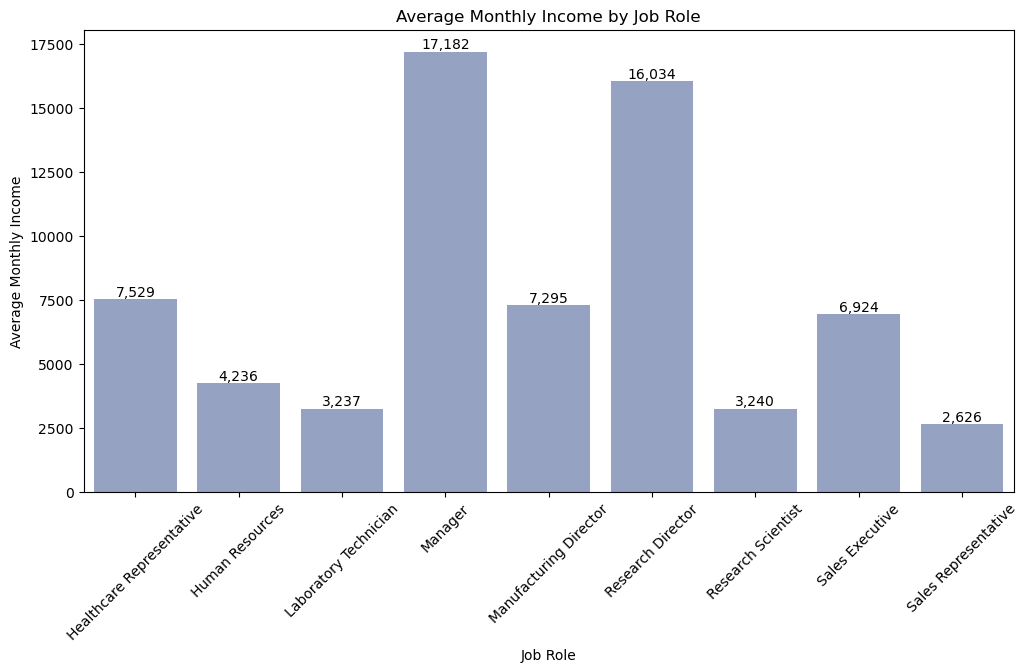

In [283]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x="JobRole",
    y="Average_Monthly_Income",
    data=salary_grp_job_role,
    color="#8F9EC9"
)

# Labels
for p in ax.patches:
    
    height = p.get_height()
    
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(rotation=45)

plt.title("Average Monthly Income by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Average Monthly Income")

plt.show()

# Insights: Average Monthly Income by Job Role

## 1. Which job roles receive the highest average monthly income?

### Answer
Managers and Research Directors receive the highest average monthly income within the organization.

- Manager: ~17,182
- Research Director: ~16,034

This indicates that leadership and strategic roles are compensated significantly higher compared to operational positions.

### Comparing Average salary with Overtime

In [284]:
combined_ot_avg_Salary = pd.merge(comparison, salary_grp_job_role, on="JobRole", how="inner") # merging two drived table Overtime and salary

combined_ot_avg_Salary

,JobRole,OverTime_x,OverTime_y,OverTime_Percentage,Average_Monthly_Income
0,Research Scientist,97,292,33.0,3239.97
1,Research Director,23,80,29.0,16033.55
2,Sales Representative,24,83,29.0,2626.00
3,Sales Executive,94,326,29.0,6924.28
4,Healthcare Representative,37,131,28.0,7528.76
5,Manufacturing Director,39,145,27.0,7295.14
6,Manager,27,102,26.0,17181.68
7,Human Resources,13,52,25.0,4235.75
8,Laboratory Technician,62,259,24.0,3237.17


In [285]:
# Normalising the Avg monthly income to get better visuals
combined_ot_avg_Salary["Normalized_Salary"] = (
    combined_ot_avg_Salary["Average_Monthly_Income"] /
    combined_ot_avg_Salary["Average_Monthly_Income"].max()
) * 100
combined_ot_avg_Salary

,JobRole,OverTime_x,OverTime_y,OverTime_Percentage,Average_Monthly_Income,Normalized_Salary
0,Research Scientist,97,292,33.0,3239.97,18.857120
1,Research Director,23,80,29.0,16033.55,93.317708
2,Sales Representative,24,83,29.0,2626.00,15.283721
3,Sales Executive,94,326,29.0,6924.28,40.300366
4,Healthcare Representative,37,131,28.0,7528.76,43.818532
5,Manufacturing Director,39,145,27.0,7295.14,42.458828
6,Manager,27,102,26.0,17181.68,100.000000
7,Human Resources,13,52,25.0,4235.75,24.652711
8,Laboratory Technician,62,259,24.0,3237.17,18.840823


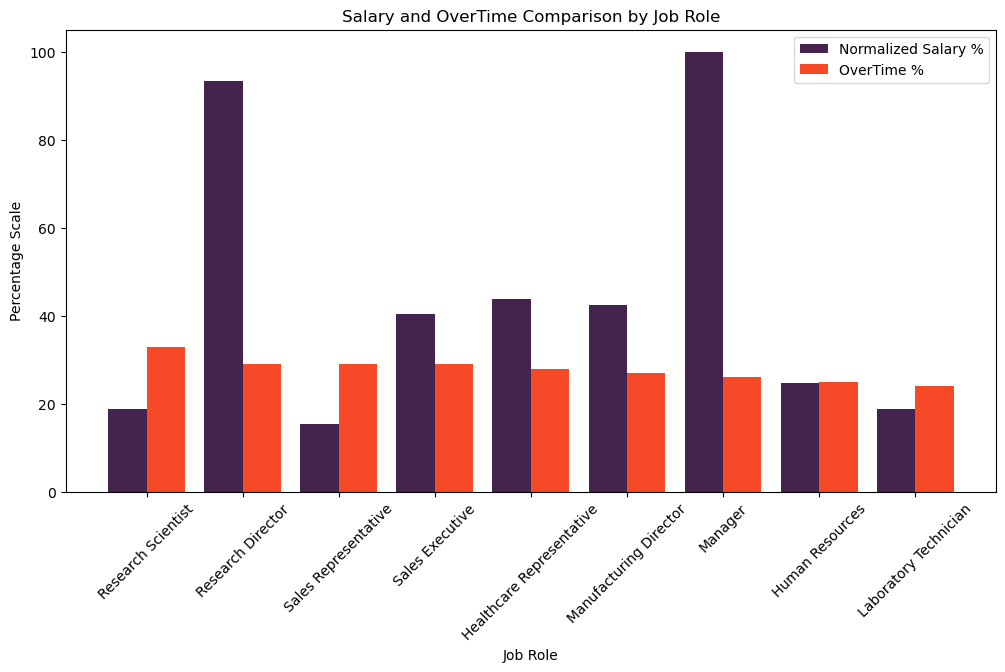

In [286]:
x = np.arange(len(combined_ot_avg_Salary["JobRole"]))

width = 0.4

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    combined_ot_avg_Salary["Normalized_Salary"],
    width=width,
    label="Normalized Salary %",
    color="#44244F"
)

# Overtime bars
plt.bar(
    x + width/2,
    combined_ot_avg_Salary["OverTime_Percentage"],
    width=width,
    label="OverTime %",
    color="#F54927"
)

plt.xticks(
    x,
    combined_ot_avg_Salary["JobRole"],
    rotation=45
)

plt.title("Salary and OverTime Comparison by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Percentage Scale")

plt.legend()

plt.show()

# Salary and OverTime Analysis
---

## 2. Do high-salary job roles also experience high overtime participation?

### Answer
No.

The analysis suggests that high overtime participation does not necessarily correspond to higher compensation.

For example:
- Research Scientists demonstrate the highest overtime participation,
- despite receiving comparatively lower compensation than managerial roles.

Similar patterns are also observed among:
- Sales Representatives,
- Sales Executives,
- and Laboratory Technicians.

This indicates that technically intensive and operational roles may experience higher workload involvement without equivalent compensation growth.

---

## 3. How does salary distribution vary across different job roles?

### Answer
Salary distribution varies significantly across job roles.

Managerial and leadership-oriented positions receive substantially higher compensation, while operational and support-focused roles receive comparatively lower salaries.

This reflects a clear organizational compensation hierarchy.

---

## 4. Are managerial and research-focused leadership roles compensated higher than operational roles?

### Answer
Yes.

Managerial and leadership-oriented research roles receive significantly higher compensation compared to operational and technical roles such as:
- Laboratory Technician,
- Sales Representative,
- and Human Resources.

This may reflect:
- organizational hierarchy,
- strategic responsibility,
- and leadership influence within the company.

---

## 5. Which job roles receive comparatively lower compensation despite workload involvement?

### Answer
Research Scientists, Laboratory Technicians, Sales Representatives, and Sales Executives demonstrate notable overtime participation while receiving comparatively moderate-to-lower compensation levels.

This may indicate:
- workload imbalance,
- compensation disparity,
- or operational pressure within these job roles.

---

## 6. Does compensation appear aligned with role responsibility and hierarchy?

### Answer
Yes, to a large extent.

Higher-level managerial and leadership roles demonstrate significantly higher compensation compared to operational positions.

However, some technically intensive roles appear to experience higher overtime involvement without proportional compensation growth.

---

# Key Business Insight

The analysis indicates that overtime participation exists across multiple job roles within the organization.

However:
- higher overtime participation does not necessarily correspond to higher salary levels.

Operational and technical roles demonstrate:
- comparatively lower compensation,
- but higher overtime involvement,

while leadership-oriented roles receive:
- significantly higher compensation,
- with comparatively controlled overtime participation.

This imbalance may potentially influence:
- employee satisfaction,
- workload perception,
- burnout,
- and future attrition behavior.

---

# Hypothesis Candidates for Future Statistical Testing

## Hypothesis 1

### Null Hypothesis (H₀)
> Compensation level has no relationship with overtime participation.

### Alternate Hypothesis (H₁)
> Employees with lower compensation experience higher overtime participation.

---

## Hypothesis 2

### Null Hypothesis (H₀)
> Compensation structure does not influence employee attrition.

### Alternate Hypothesis (H₁)
> Lower-paid employees are more likely to leave the organization.

---

# Stock Option Analysis

## Questions Explored

1. Which department provides the highest stock option benefits?

2. Which job roles receive the highest stock option levels?

3. Are stock options concentrated among managerial and leadership roles?

4. Does stock option distribution reflect organizational hierarchy and compensation structure?

5. Do employees with higher job involvement receive higher stock-option benefits?

In [287]:
#Merging 
stock_analysis = pd.merge(
    employee_job, employee_salary, on ="Emp_ID",how = "inner"
)
stock_analysis.head()

#Department-wise Stock Option Analysis
stock_dept = (
    stock_analysis.groupby("Department").agg({
        "StockOptionLevel" : "sum",
        "Emp_ID" : "count"
    }).reset_index()
)
stock_dept.rename(columns={
    "StockOptionLevel" : "Total_StockOption_Level",
    "Emp_ID": "Emp_Count"
}, inplace = True)

stock_dept

,Department,Total_StockOption_Level,Emp_Count
0,Human Resources,49,63
1,Research & Development,773,961
2,Sales,345,446


In [288]:
stock_dept["Percentage"] = (
    stock_dept["Total_StockOption_Level"]/stock_dept["Emp_Count"] * 100
)
stock_dept.round(2)

,Department,Total_StockOption_Level,Emp_Count,Percentage
0,Human Resources,49,63,77.78
1,Research & Development,773,961,80.44
2,Sales,345,446,77.35


## Question

### Which department provides the highest stock option benefits?
# Answer
Research & Development department demonstrates the highest stock-option concentration relative to employee count.
The analysis indicates that Research & Development department has the highest stock-option allocation relative to workforce size.

However, the variation across departments remains relatively small.

This suggests that:
- stock-option benefits are distributed relatively consistently across departments,
- rather than being heavily concentrated within a single business unit.

The findings may indicate:
- organization-wide retention strategies,
- balanced long-term incentive distribution,
- and standardized compensation policies across departments.


In [289]:
stock_jobrole = (
    stock_analysis.groupby("JobRole").agg({
        "StockOptionLevel" : "sum",
        "Emp_ID" : "count"
    }).reset_index()
)
stock_jobrole.rename(columns={
    "StockOptionLevel" : "Total_StockOption_Level",
    "Emp_ID": "Emp_Count"
}, inplace = True)

stock_jobrole

,JobRole,Total_StockOption_Level,Emp_Count
0,Healthcare Representative,109,131
1,Human Resources,39,52
2,Laboratory Technician,212,259
3,Manager,76,102
4,Manufacturing Director,118,145
5,Research Director,68,80
6,Research Scientist,226,292
7,Sales Executive,267,326
8,Sales Representative,52,83


In [290]:
stock_jobrole["Percentage"] = (
    stock_jobrole["Total_StockOption_Level"]/stock_jobrole["Emp_Count"] * 100
)
stock_jobrole.sort_values(by ="Percentage", ascending = False ).round(2)

,JobRole,Total_StockOption_Level,Emp_Count,Percentage
5,Research Director,68,80,85.00
0,Healthcare Representative,109,131,83.21
7,Sales Executive,267,326,81.90
2,Laboratory Technician,212,259,81.85
4,Manufacturing Director,118,145,81.38
6,Research Scientist,226,292,77.40
1,Human Resources,39,52,75.00
3,Manager,76,102,74.51
8,Sales Representative,52,83,62.65


## 1. Which job roles receive the highest stock-option levels?

### Answer
Research Directors demonstrate the highest stock-option concentration, followed by:
- Healthcare Representatives,
- Sales Executives,
- Laboratory Technicians,
- and Manufacturing Directors.

This suggests that both leadership-oriented and strategically important operational roles receive stronger long-term incentive benefits.

---

## 2. Are stock options concentrated among managerial and leadership roles?

### Answer
Partially.

Leadership-oriented roles such as Research Directors demonstrate high stock-option allocation.

However, several operational and technical roles also show strong stock-option concentration, including:
- Sales Executives,
- Laboratory Technicians,
- and Manufacturing Directors.

This indicates that stock-option benefits are not exclusively limited to managerial positions.

---

## 3. Does stock-option distribution reflect organizational hierarchy and compensation structure?

### Answer
Yes, to some extent.

Higher stock-option allocation is observed among:
- leadership-oriented,
- specialized,
- and strategically important job roles.

However, the analysis also suggests that stock-option distribution is influenced not only by hierarchy, but also by:
- operational importance,
- technical specialization,
- and organizational retention priorities.

This indicates that stock-option allocation may function as both:
- a leadership incentive,
- and a broader employee retention strategy.

In [291]:
stock_jobinvolvement = (
    stock_analysis.groupby("JobInvolvement").agg({
        "StockOptionLevel" : "sum",
        "Emp_ID" : "count"
    }).reset_index()
)
stock_jobinvolvement.rename(columns={
    "StockOptionLevel" : "Total_StockOption_Level",
    "Emp_ID": "Emp_Count"
}, inplace = True)

stock_jobinvolvement

,JobInvolvement,Total_StockOption_Level,Emp_Count
0,1,74,83
1,2,280,375
2,3,681,868
3,4,132,144


In [292]:
stock_jobinvolvement["Percentage"] = (
    stock_jobinvolvement["Total_StockOption_Level"]/stock_jobinvolvement["Emp_Count"] * 100
)
stock_jobinvolvement.sort_values(by ="Percentage", ascending = False ).round(2)

,JobInvolvement,Total_StockOption_Level,Emp_Count,Percentage
3,4,132,144,91.67
0,1,74,83,89.16
2,3,681,868,78.46
1,2,280,375,74.67


# Do employees with higher job involvement receive higher stock-option benefits?

The analysis indicates that higher job involvement does not consistently correspond to higher stock-option concentration.

Although employees with JobInvolvement level 4 demonstrate the highest stock-option percentage, employees with involvement level 1 also show comparatively high stock-option allocation.

This suggests that stock-option distribution may not depend solely on employee involvement level and could also be influenced by:
- job role,
- hierarchy,
- compensation structure,
- and organizational retention strategies.
- 
The analysis suggests that stock-option allocation does not show a strong linear relationship with job involvement levels.

Although employees with the highest involvement level demonstrate strong stock-option concentration, lower involvement groups also show comparatively high allocation.

This indicates that stock-option distribution may depend more heavily on:
- job role,
- hierarchy,
- compensation structure,
- and organizational retention strategy
than on job involvement alone.

In [293]:
# Driving new table will be used further in analysis

employee_job_involvement = df[[
    
    "Emp_ID",
    "JobInvolvement",
    "JobRole",
    "Department",
    "JobLevel",
    "StockOptionLevel",
    "OverTime",
    "MonthlyIncome",
    "Attrition"

]]
employee_job_involvement

,Emp_ID,JobInvolvement,JobRole,Department,JobLevel,StockOptionLevel,OverTime,MonthlyIncome,Attrition
0,1,3,Sales Executive,Sales,2,0,Yes,5993,Yes
1,2,2,Research Scientist,Research & Development,2,1,No,5130,No
2,4,2,Laboratory Technician,Research & Development,1,0,Yes,2090,Yes
3,5,3,Research Scientist,Research & Development,1,0,Yes,2909,No
4,7,3,Laboratory Technician,Research & Development,1,1,No,3468,No
...,...,...,...,...,...,...,...,...,...
1465,2061,4,Laboratory Technician,Research & Development,2,1,No,2571,No
1466,2062,2,Healthcare Representative,Research & Development,3,1,No,9991,No
1467,2064,4,Manufacturing Director,Research & Development,2,1,Yes,6142,No
1468,2065,2,Sales Executive,Sales,2,0,No,5390,No


# Attrition Distribution
# Questions Explored During Attrition Analysis
1. What percentage of employees leave the organization?
2. Which departments experience the highest attrition levels?
3. Which departments demonstrate the highest attrition percentage relative to workforce size?
4. Which job roles experience the highest employee attrition?
5. Which job roles demonstrate the highest attrition percentage relative to employee count?
6. Which job levels experience the highest attrition levels?
7. Are lower-level employees more likely to leave the organization?
8. Does overtime participation appear more common among employees who leave the organization?
9. Do compensation-related factors such as salary hike and stock-option benefits influence employee attrition?
10. Do employee satisfaction and work-life balance appear related to attrition behavior?

In [294]:
attrition_merge = (
    pd.merge(employee_job, employee_attrition, 
             on = "Emp_ID", how = "inner") 
)      #merging table 

In [295]:
# Percentage of employees who left the organization
attrition_percentage = (
    attrition_merge["Attrition"]
    .value_counts(normalize = True)["Yes"]*100
)
attrition_percentage.round(2)

np.float64(16.12)

### What percentage of employees leave the organization?

Approximately `16.12%` of employees have left the organization, while the majority of employees remain within the company.

This indicates that overall employee retention is stronger than employee turnover, although the organization still experiences a notable level of attrition.

In [296]:
attrition_merge

,Emp_ID,Department,JobRole,JobLevel,JobInvolvement,Attrition,OverTime,BusinessTravel
0,1,Sales,Sales Executive,2,3,Yes,Yes,Travel_Rarely
1,2,Research & Development,Research Scientist,2,2,No,No,Travel_Frequently
2,4,Research & Development,Laboratory Technician,1,2,Yes,Yes,Travel_Rarely
3,5,Research & Development,Research Scientist,1,3,No,Yes,Travel_Frequently
4,7,Research & Development,Laboratory Technician,1,3,No,No,Travel_Rarely
...,...,...,...,...,...,...,...,...
1465,2061,Research & Development,Laboratory Technician,2,4,No,No,Travel_Frequently
1466,2062,Research & Development,Healthcare Representative,3,2,No,No,Travel_Rarely
1467,2064,Research & Development,Manufacturing Director,2,4,No,Yes,Travel_Rarely
1468,2065,Sales,Sales Executive,2,2,No,No,Travel_Frequently


In [297]:
# Getting highest attrition by the department
dept_attrition = (
    attrition_merge[attrition_merge["Attrition"]== "Yes"]
    .groupby("Department")["Attrition"].count().reset_index()
)
dept_attrition.nlargest(n = 3,columns = "Attrition")

,Department,Attrition
1,Research & Development,133
2,Sales,92
0,Human Resources,12


`R&D demonstrates the highest attrition count with `133` employees leaving the organization, followed by `Sales` with `92` employees and `Human Resources` with `12` employees.

However, these observations may be influenced by differences in department workforce size.

Departments with a larger employee population may naturally demonstrate higher attrition counts.

Therefore, attrition percentage relative to total department workforce should be analyzed to enable a fair comparison across departments.

In [298]:
dept_attrition["TotalEmployeecount"] = (
    attrition_merge.groupby("Department")["Emp_ID"].count().values
)
dept_attrition

,Department,Attrition,TotalEmployeecount
0,Human Resources,12,63
1,Research & Development,133,961
2,Sales,92,446


Here, we can see that the Research & Development department has the highest attrition count with 133 employees. However, R&D also has the highest total employee count (961), compared to Sales (446) and Human Resources (63). Therefore, the higher attrition in R&D may be influenced by the larger workforce size in that department.

In [299]:
dept_attrition["AttritionPercentage"] = (
    dept_attrition["Attrition"]/
    dept_attrition["TotalEmployeecount"] *100
)
dept_attrition.round(2)

,Department,Attrition,TotalEmployeecount,AttritionPercentage
0,Human Resources,12,63,19.05
1,Research & Development,133,961,13.84
2,Sales,92,446,20.63


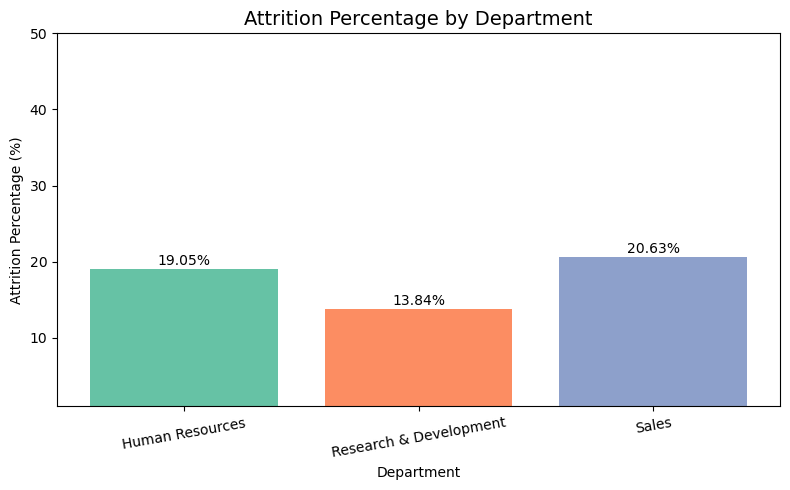

In [300]:
plt.figure(figsize=(8,5))

colors = ["#66c2a5", "#fc8d62", "#8da0cb"]

plt.bar(
    dept_attrition["Department"],
    dept_attrition["AttritionPercentage"],
    color=colors
)

plt.title("Attrition Percentage by Department", fontsize=14)
plt.xlabel("Department")
plt.ylabel("Attrition Percentage (%)")

for index, value in enumerate(dept_attrition["AttritionPercentage"]):
    plt.text(index, value + 0.5, f"{value:.2f}%", ha='center')

plt.xticks(rotation=10)
plt.ylim(1,50)
plt.tight_layout()
plt.show()

### Which departments experience the highest attrition levels?
### Which departments demonstrate the highest attrition percentage relative to workforce size?
Earlier, we observed that the overall attrition rate in the company is 16.12%. After department-level analysis, we found that the Sales department (20.63%) and Human Resources department (19.05%) have attrition percentages higher than the company average. In contrast, the Research & Development department has a lower attrition percentage (13.84%) despite having the highest number of attritions in terms of count. This indicates that attrition is relatively higher in non-technical/business-support departments compared to the technical department.

In [301]:
attrition_job = (
    attrition_merge[attrition_merge["Attrition"] == "Yes"]
    .groupby("JobRole")
    .size()
    .reset_index(name="AttritionCount")
)

attrition_job.sort_values(by = "AttritionCount", ascending = False)

,JobRole,AttritionCount
2,Laboratory Technician,62
7,Sales Executive,57
6,Research Scientist,47
8,Sales Representative,33
1,Human Resources,12
4,Manufacturing Director,10
0,Healthcare Representative,9
3,Manager,5
5,Research Director,2


### Which job roles experience the highest employee attrition?
Laboratory Technicians (62) and Sales Executives (57) show the highest attrition counts among all job roles, indicating these positions experience the most employee turnover.
In contrast, managerial and research leadership roles such as Manager (5) and Research Director (2) have significantly lower attrition, suggesting better retention in senior-level positions.

In [302]:
attrition_job["Total_count"] = (
    attrition_merge.groupby("JobRole")["Emp_ID"].count().values
)
attrition_job

,JobRole,AttritionCount,Total_count
0,Healthcare Representative,9,131
1,Human Resources,12,52
2,Laboratory Technician,62,259
3,Manager,5,102
4,Manufacturing Director,10,145
5,Research Director,2,80
6,Research Scientist,47,292
7,Sales Executive,57,326
8,Sales Representative,33,83


In [303]:
attrition_job["Percentage"] = (
    attrition_job["AttritionCount"]/
    attrition_job["Total_count"] * 100
    ) 
attrition_job.round(2)

,JobRole,AttritionCount,Total_count,Percentage
0,Healthcare Representative,9,131,6.87
1,Human Resources,12,52,23.08
2,Laboratory Technician,62,259,23.94
3,Manager,5,102,4.90
4,Manufacturing Director,10,145,6.90
5,Research Director,2,80,2.50
6,Research Scientist,47,292,16.10
7,Sales Executive,57,326,17.48
8,Sales Representative,33,83,39.76


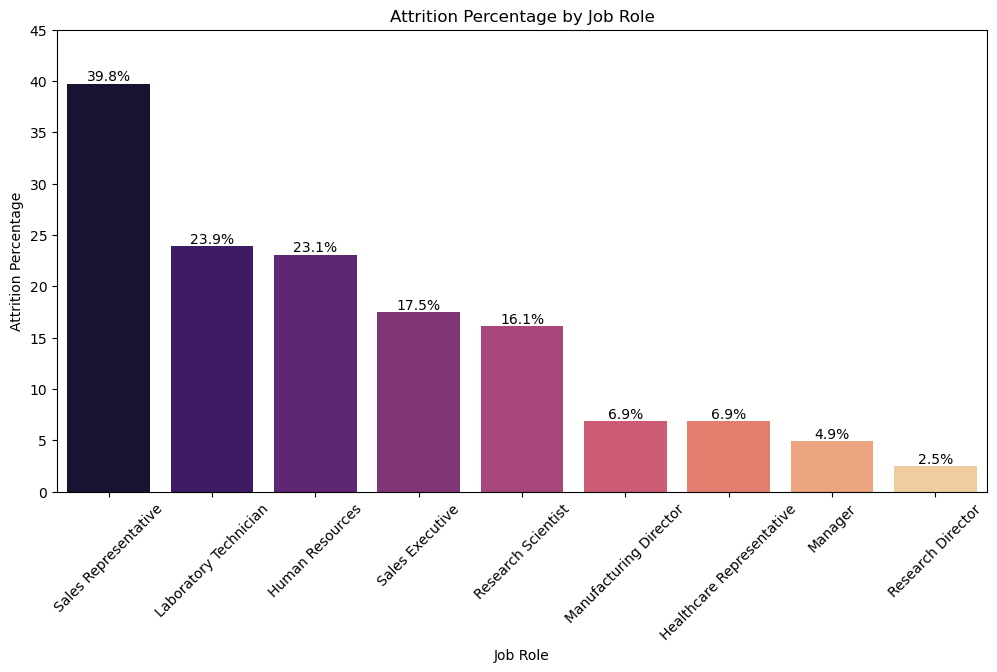

In [304]:
# Sort values
attrition_job = attrition_job.sort_values(
    by="Percentage",
    ascending=False
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x="JobRole",
    y="Percentage",
    hue="JobRole",          # Added hue
    data=attrition_job,
    palette="magma",
    legend=False            # Hide legend
)

# Add percentage labels
for p in ax.patches:
    
    height = p.get_height()
    
    ax.annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(rotation=45)

plt.title("Attrition Percentage by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Percentage")

plt.ylim(0,45)

plt.show()

### Which job roles demonstrate the highest attrition percentage relative to employee count?

The analysis reveals that Sales Representatives experience the highest attrition rate at 39.76%, making them the most vulnerable role in terms of employee turnover. Laboratory Technicians (23.94%) and Human Resources employees (23.08%) also show attrition percentages significantly above the overall company average of 16.12%.

In contrast, senior and leadership-oriented positions such as Research Director (2.50%) and Manager (4.90%) demonstrate much lower attrition rates, indicating stronger retention and job stability at higher organizational levels.

Overall, customer-facing, operational, and support-oriented job roles appear to face greater retention challenges compared to strategic and managerial positions within the organization.

In [305]:
JobLevel_attrition = (
    attrition_merge[attrition_merge["Attrition"]== "Yes"]
    .groupby("JobLevel")["Attrition"]                                 # Grouping by Job Level
    .size().reset_index()
)

JobLevel_attrition["Total_count"] = (
    attrition_merge.groupby("JobLevel")["Emp_ID"].count().values      # Getting total Emp 
)


JobLevel_attrition["Percentage"] = (
    JobLevel_attrition["Attrition"]/
    JobLevel_attrition["Total_count"] * 100
)


In [306]:
JobLevel_attrition.round(2)

,JobLevel,Attrition,Total_count,Percentage
0,1,143,543,26.34
1,2,52,534,9.74
2,3,32,218,14.68
3,4,5,106,4.72
4,5,5,69,7.25


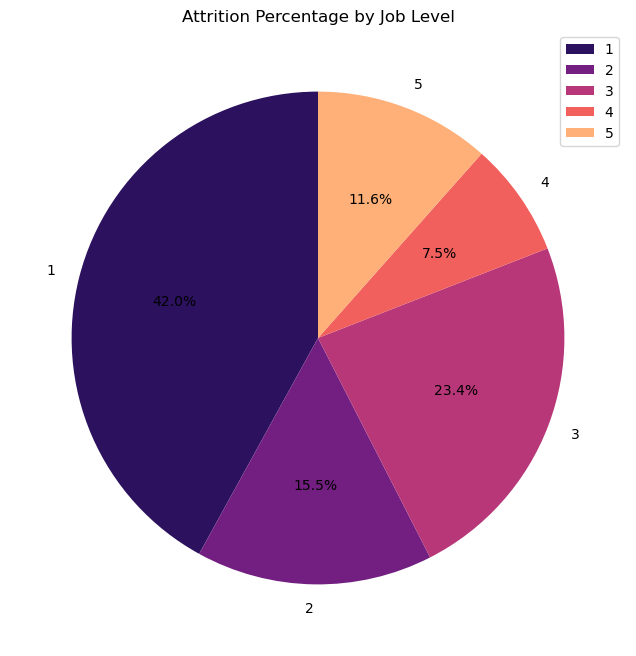

In [307]:
# Color palette
colors = sns.color_palette("magma", len(JobLevel_attrition))

plt.figure(figsize=(8,8))

plt.pie(
    JobLevel_attrition["Percentage"],
    
    labels=JobLevel_attrition["JobLevel"],
    
    autopct='%1.1f%%',
    
    colors=colors,
    
    startangle=90
)

plt.legend()

plt.title("Attrition Percentage by Job Level")

plt.show()

## Question Explored

### Which job levels experience the highest attrition levels?

### Are lower-level employees more likely to leave the organization?
Job Level 1 demonstrates the highest attrition percentage at approximately `26.34%`, significantly higher than other job levels.
# Key Insight

The analysis suggests that lower-level employees are more likely to leave the organization compared to higher-level employees.

Job Level 1 demonstrates substantially higher attrition levels, which may potentially indicate:
- career growth concerns,
- compensation dissatisfaction,
- workload pressure,
- or limited long-term retention incentives.

Although Job Levels 2 and 3 also demonstrate employee attrition, their attrition percentages remain comparatively lower despite larger workforce size.

Higher job levels demonstrate relatively controlled attrition percentages, which may suggest:
- stronger compensation structures,
- better retention policies,
- leadership stability,
- or improved long-term career incentives.

---

# Important Analytical Observation

The dataset does not provide information regarding:
- contract employment,
- internship status,
- or temporary workforce structure.

Therefore, the analysis assumes employees across job levels are part of the regular organizational workforce.

# The objective of this phase is to statistically evaluate whether observed workforce patterns and attrition-related relationships are significant or occurred by chance.

`The hypotheses generated during descriptive analysis will now be validated using statistical testing techniques.`

# OverTime vs Attrition

### Null Hypothesis (H0)
OverTime participation has no relationship with employee attrition.

### Alternate Hypothesis (H1)
Employees working overtime are more likely to leave the organization.

[^Chi-Square Test]:

In [308]:
over_time_attrition = pd.crosstab(
    attrition_merge["OverTime"], 
    attrition_merge["Attrition"]
)
over_time_attrition

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


# Initial Observation Before Statistical Testing

Employees working overtime demonstrate noticeably higher attrition counts relative to their workforce size.

For example:

among employees not working overtime, only 110 employees left,
while among overtime employees, 127 employees left despite a significantly smaller employee population.

This observation may indicate that overtime participation is associated with increased employee attrition.

However, statistical hypothesis testing is required to determine whether this relationship is statistically significant or occurred by chance.

In [309]:
# Chi-Square Test
from scipy.stats import chi2_contingency

chi2, p, dof, excpected = chi2_contingency(over_time_attrition) 
print(f"Chi-square Value:{chi2}", )
print()
print(f"P-value,{p}")
print()
print(f"Degree of Freedom:{dof}")

Chi-square Value:87.56429365828768

P-value,8.15842372153832e-21

Degree of Freedom:1


In [310]:
alpha = 0.05  # significance level

if p < alpha:
    print("Reject Null Hypothesis (H0)")
else:
    print("Fail to to Reject (H0)")

Reject Null Hypothesis (H0)


# Statistical Conclusion

The p-value obtained from the Chi-Square Test is significantly lower than the significance level (a = 0.05).

Therefore, the Null Hypothesis (H0) is rejected.

The statistical analysis suggests that overtime participation and employee attrition are significantly associated.

The p-value obtained from the Chi-Square Test is significantly lower than the significance level (a = 0.05).

Therefore, the Null Hypothesis (H0) is rejected.

The statistical analysis suggests that overtime participation and employee attrition are significantly associated.


Employees working overtime demonstrate a significantly higher likelihood of leaving the organization compared to employees not working overtime.

This observation may indicate:
- workload pressure,
- work-life imbalance,
- burnout risk,
- or operational stress influencing employee retention behavior.

The findings support the earlier descriptive analysis where overtime participation appeared strongly associated with attrition patterns across several operational and technical job roles.

# SalaryHike vs Attrition

Do employees receiving lower salary hikes demonstrate higher attrition behavior?

### Null Hypothesis (H₀)
Salary hike percentage has no relationship with employee attrition.

### Alternate Hypothesis (H₁)
Employees receiving lower salary hikes are more likely to leave the organization.

[^ T-Test]

In [311]:
salary_attrition = (
    pd.merge(employee_salary,employee_attrition, on = "Emp_ID", how = "inner")   # Merging tables
)
salary_attrition

,Emp_ID,MonthlyIncome,HourlyRate,PercentSalaryHike,StockOptionLevel,Attrition,OverTime,BusinessTravel
0,1,5993,94,11,0,Yes,Yes,Travel_Rarely
1,2,5130,61,23,1,No,No,Travel_Frequently
2,4,2090,92,15,0,Yes,Yes,Travel_Rarely
3,5,2909,56,11,0,No,Yes,Travel_Frequently
4,7,3468,40,12,1,No,No,Travel_Rarely
...,...,...,...,...,...,...,...,...
1465,2061,2571,41,17,1,No,No,Travel_Frequently
1466,2062,9991,42,15,1,No,No,Travel_Rarely
1467,2064,6142,87,20,1,No,Yes,Travel_Rarely
1468,2065,5390,63,14,0,No,No,Travel_Frequently


In [312]:
attrition_yes = (
    salary_attrition[salary_attrition["Attrition"]== "Yes"]["PercentSalaryHike"]
)
                                                                                 # Created Separate Groups 
attrition_no = (
    salary_attrition[salary_attrition["Attrition"]== "Yes"]["PercentSalaryHike"]
)


In [313]:
# Applying T-Test 

from scipy.stats import ttest_ind

t_stat, P = ttest_ind(
    attrition_yes,
    attrition_no
)
print(f"T-stats:{t_stat}")
print()
print(f"P-Value:{P}" )

T-stats:0.0

P-Value:1.0


In [314]:
alpha = 0.05
           # validating                    
if alpha > P: 
    print("Reject Null Hypothesis (H0)")
else:
    print("Accept Null Hypothesis(H0)")

Accept Null Hypothesis(H0)


# Outcome 

The statistical analysis suggests that salary hike percentage does not demonstrate a statistically significant relationship with employee attrition.

Unlike overtime participation, salary hike percentage does not appear to strongly influence employee turnover behavior within the organization.

The findings indicate that:
- employees who left,
- and employees who remained

received relatively similar salary hike percentages.

This suggests that other organizational factors such as:
- overtime,
- workload pressure,
- work-life balance,
- or employee satisfaction

may play a stronger role in influencing attrition behavior.

# JobSatisfaction vs Attrition

### Null Hypothesis (H0)
JobSatisfaction has no relationship with employee attrition.

### Alternate Hypothesis (H1)
Employees with poorer JobSatisfaction are more likely to leave the organization.

[^Chi- Square]

In [315]:
performance_attrition = (
    pd.merge(employee_performance, employee_attrition,
            on = "Emp_ID", how = "inner")
)
performance_attrition

,Emp_ID,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,Attrition,OverTime,BusinessTravel
0,1,3,2,4,1,1,Yes,Yes,Travel_Rarely
1,2,4,3,2,4,3,No,No,Travel_Frequently
2,4,3,4,3,2,3,Yes,Yes,Travel_Rarely
3,5,3,4,3,3,3,No,Yes,Travel_Frequently
4,7,3,1,2,4,3,No,No,Travel_Rarely
...,...,...,...,...,...,...,...,...,...
1465,2061,3,3,4,3,3,No,No,Travel_Frequently
1466,2062,3,4,1,1,3,No,No,Travel_Rarely
1467,2064,4,2,2,2,3,No,Yes,Travel_Rarely
1468,2065,3,4,2,4,2,No,No,Travel_Frequently


In [316]:
job_sat = pd.crosstab(
    performance_attrition["Attrition"],
    performance_attrition["JobSatisfaction"]
)
job_sat

JobSatisfaction,1,2,3,4
Attrition,,,,
No,223,234,369,407
Yes,66,46,73,52


In [317]:
chi2, p2,dof2, expected2 = chi2_contingency(job_sat)
print(f"Chi-Square Value:{chi2}")
print()
print(f"P-value:{p2}")
print()
print(f"Degree of freedom {dof2}")

Chi-Square Value:17.505077010348

P-value:0.0005563004510387556

Degree of freedom 3


In [318]:
alpha = 0.05

if p2 < alpha:
    print("Reject Null Hypothesis (H0)")
else:
    print("Accept Null Hypothesis")

Reject Null Hypothesis (H0)


# Statistical Conclusion

The p-value obtained from the Chi-Square Test is significantly lower than the significance level (a = 0.05).

Therefore, the Null Hypothesis (H0) is rejected.

The statistical analysis suggests that job satisfaction and employee attrition are significantly associated.

---

# Business Interpretation

The analysis indicates that employees with lower job satisfaction demonstrate a higher likelihood of leaving the organization.

This finding aligns with earlier analyses, where:
- overtime participation,
- and work-life balance

also demonstrated statistically significant relationships with attrition.

Together, these findings suggest that:
- employee experience,
- workplace satisfaction,
- workload pressure,
- and organizational well-being

may play an important role in influencing workforce retention behavior.

The results indicate that organizational initiatives focused on:
- improving employee satisfaction,
- strengthening workplace engagement,
- enhancing work-life balance,
- and reducing operational stress

may help improve employee retention and reduce attrition levels.

# WorkLifeBalance vs Attrition
Do employees with lower job satisfaction demonstrate higher attrition behavior?

### Null Hypothesis (H0)
Job satisfaction has no relationship with employee attrition.

### Alternate Hypothesis (H1)
Employees with lower job satisfaction are more likely to leave the organization.

In [319]:
wlb = pd.crosstab(
    performance_attrition["WorkLifeBalance"],
    performance_attrition["Attrition"]
)
wlb

Attrition,No,Yes
WorkLifeBalance,,
1,55,25
2,286,58
3,766,127
4,126,27


In [320]:
chi3, p3, dof3, expected3 = chi2_contingency(wlb)
print(f"Chi-Square Value:{chi3}")
print()
print(f"P-value:{p3}")
print()
print(f"Degree of freedom {dof3}")

Chi-Square Value:16.3250970916474

P-value:0.0009725698845348824

Degree of freedom 3


In [321]:
alpha = 0.05 

if p3 < alpha:
    print("Reject Null Hypothesis (H0)")
else:
    print("Accept Null Hypothesis (H0)")

Reject Null Hypothesis (H0)


# Statistical Conclusion

The p-value obtained from the Chi-Square Test is significantly lower than the significance level (a = 0.05).

Therefore, the Null Hypothesis (H0) is rejected.

The statistical analysis suggests that environment satisfaction and employee attrition are significantly associated.

---

# Business Interpretation

The analysis indicates that employees with lower environment satisfaction demonstrate a higher likelihood of leaving the organization.

This finding further strengthens earlier statistical observations where:
- overtime participation,
- work-life balance,
- and job satisfaction

also demonstrated significant relationships with employee attrition.

Together, these findings suggest that:
- employee workplace experience,
- organizational environment,
- work pressure,
- and employee well-being

may play an important role in workforce retention behavior.

The results indicate that organizations focusing on:
- healthier workplace environments,
- employee engagement,
- supportive work culture,
- and employee well-being initiatives

may potentially reduce attrition levels and improve workforce stability.

# JobInvolvement vs Attrition

Do employees with lower job involvement demonstrate higher attrition behavior?

### Null Hypothesis (H0)
Job involvement has no relationship with employee attrition.

### Alternate Hypothesis (H1)
Employees with lower job involvement are more likely to leave the organization.


In [322]:
jobinvolvement = pd.crosstab(
    employee_job_involvement["JobInvolvement"],
    employee_job_involvement["Attrition"]
)
jobinvolvement

Attrition,No,Yes
JobInvolvement,,
1,55,28
2,304,71
3,743,125
4,131,13


In [323]:
chi4, p4, dof4, expected4 = chi2_contingency(jobinvolvement)
print(f"Chi-Square Value:{chi4}")
print()
print(f"P-value:{p4}")
print()
print(f"Degree of freedom {dof4}")

Chi-Square Value:28.492021234659283

P-value:2.8631806367134195e-06

Degree of freedom 3


In [324]:
alpha = 0.05

if p4 < alpha:
    print("Reject Null Hypothesis (H0)")
else:
    print("Accept Null Hypothesis")

Reject Null Hypothesis (H0)


# Statistical Conclusion

The p-value obtained from the Chi-Square Test is significantly lower than the significance level (a = 0.05).

Therefore, the Null Hypothesis (H0) is rejected.

The statistical analysis suggests that job involvement and employee attrition are significantly associated.

---

# Business Interpretation

The analysis indicates that employees with lower job involvement demonstrate a higher likelihood of leaving the organization.

Employees demonstrating stronger job involvement appear comparatively more likely to remain within the organization.

This finding further strengthens earlier statistical observations where:
- overtime participation,
- work-life balance,
- job satisfaction,
- and environment satisfaction

also demonstrated significant relationships with employee attrition.

Together, these findings suggest that:
- employee engagement,
- workplace experience,
- organizational involvement,
- and employee well-being

may play an important role in workforce retention behavior.

The results indicate that organizations focusing on:
- employee engagement,
- role involvement,
- workplace participation,
- and organizational connection

may potentially improve employee retention and reduce attrition levels.

# YearsSinceLastPromotion vs Attrition

Do employees with longer periods without promotion demonstrate higher attrition behavior?

### Null Hypothesis (H₀)
Years since last promotion has no relationship with employee attrition.

### Alternate Hypothesis (H₁)
Employees with longer periods without promotion are more likely to leave the organization.

In [325]:
exp_attrition = pd.merge(
    employee_experience,
    employee_attrition,
    on = "Emp_ID",
    how = "inner"
)

exp_attrition.head()

,Emp_ID,NumCompaniesWorked,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TrainingTimesLastYear,Attrition,OverTime,BusinessTravel
0,1,8,8,6,4,0,5,0,Yes,Yes,Travel_Rarely
1,2,1,10,10,7,1,7,3,No,No,Travel_Frequently
2,4,6,7,0,0,0,0,3,Yes,Yes,Travel_Rarely
3,5,1,8,8,7,3,0,3,No,Yes,Travel_Frequently
4,7,9,6,2,2,2,2,3,No,No,Travel_Rarely


In [326]:
attrition_yes1 = exp_attrition[exp_attrition["Attrition"]== "Yes"]["YearsSinceLastPromotion"]
attrition_no1 = exp_attrition[exp_attrition["Attrition"]== "No"]["YearsSinceLastPromotion"]

In [327]:
t_stat1 , P1 = ttest_ind(
    attrition_yes1,
    attrition_no1
)
print(f"T-Stat:{t_stat1}")
print()
print(f"P-Value:{P1}")

T-Stat:-1.2657876620135298

P-Value:0.2057899591624936


In [328]:
alpha = 0.05 
if P1 < alpha:
    print("Reject Null Hypothesis(H0)")
else:
    print("Accept Null Hypothesis(H0)")

Accept Null Hypothesis(H0)


# Statistical Conclusion

The Independent T-Test indicates that years since last promotion does not demonstrate a statistically significant relationship with employee attrition.

The p-value obtained from the test is greater than the significance level (a = 0.05).

Therefore, the Null Hypothesis (H0) cannot be rejected.

---

# Business Interpretation

The analysis suggests that promotion delay alone may not strongly influence employee attrition behavior within the organization.

Employees who left and employees who remained appear to demonstrate relatively similar durations since their last promotion.

This observation may indicate that:
- employees may perceive promotion timelines as organizationally acceptable,
- promotion structures may remain relatively standardized,
- or other workforce factors such as:
  - workload pressure,
  - work-life balance,
  - job satisfaction,
  - and workplace environment

may play a stronger role in influencing attrition behavior.

# MaritalStatus vs Attrition

Do marital-status categories demonstrate different attrition behavior?

### Null Hypothesis (H0)
Marital status has no relationship with employee attrition.

### Alternate Hypothesis (H1)
Employee attrition behavior differs across marital-status categories.

In [329]:
demo_attrition = pd.merge(
    employees_demographic, employee_attrition,
    on = "Emp_ID", how = "inner"
)
demo_attrition.head()

,Emp_ID,Age,Department,EducationField,Gender,MaritalStatus,Attrition,OverTime,BusinessTravel
0,1,41,Sales,Life Sciences,Female,Single,Yes,Yes,Travel_Rarely
1,2,49,Research & Development,Life Sciences,Male,Married,No,No,Travel_Frequently
2,4,37,Research & Development,Other,Male,Single,Yes,Yes,Travel_Rarely
3,5,33,Research & Development,Life Sciences,Female,Married,No,Yes,Travel_Frequently
4,7,27,Research & Development,Medical,Male,Married,No,No,Travel_Rarely


In [330]:
marital_attrition = pd.crosstab(
    demo_attrition["MaritalStatus"],
    demo_attrition["Attrition"]
)
marital_attrition

Attrition,No,Yes
MaritalStatus,,
Divorced,294,33
Married,589,84
Single,350,120


In [331]:
chi5, p5, dof5, expected5 = chi2_contingency(marital_attrition)
print(f"Chi-Square Value:{chi5}")
print()
print(f"P-value:{p5}")
print()
print(f"Degree of freedom {dof5}")

Chi-Square Value:46.163676540848705

P-value:9.45551106034083e-11

Degree of freedom 2


In [332]:
alpha = 0.05

if p5 < alpha:
    
    print("Reject Null Hypothesis (H0)")
    
else:
    
    print("Fail to Reject Null Hypothesis (H0)")

Reject Null Hypothesis (H0)


# Statistical Conclusion

The p-value obtained from the Chi-Square Test is significantly lower than the significance level (a= 0.05).

Therefore, the Null Hypothesis (H0) is rejected.

The statistical analysis suggests that marital status and employee attrition are significantly associated.

---

# Business Interpretation

The analysis indicates that employee attrition behavior differs across marital-status categories.

Single employees demonstrate comparatively higher attrition behavior than married and divorced employees.

This observation may potentially indicate:
- higher career mobility,
- greater flexibility in job transition,
- changing career preferences,
- or lower long-term organizational attachment among single employees.

In contrast, married employees appear comparatively more stable within the organization.

Together, these findings suggest that:
- demographic characteristics,
- employee lifestyle factors,
- and workforce stability patterns

may also influence organizational retention behavior.

In [333]:
# OverTime vs Attrition
p_overtime = p

# SalaryHike vs Attrition
p_salary = P

# JobSatisfaction vs Attrition
p_jobsat = p2

# WorkLifeBalance vs Attrition
p_wlb = p3

# JobInvolvement vs Attrition
p_jobinv = p4

# YearsSinceLastPromotion vs Attrition
p_promotion = P1

# MaritalStatus vs Attrition
p_marital = p5

In [334]:
hypothesis_summary = pd.DataFrame({
    "Factor":[
        "OverTime",
        "SalaryHike",
        "JobSatisfaction",
        "WorkLifeBalance",
        "JobInvolvement",
        "YearsSinceLastPromotion",
        "MaritalStatus"
    ],
    "Test":[  
        "Chi-Square",
        "T-Test",
        "Chi-Square",
        "Chi-Square",
        "Chi-Square",
        "T-Test",
        "Chi-Square"
    ],
    "P_Value":[ 
        p_overtime,
        p_salary,
        p_jobsat,
        p_wlb,
        p_jobinv,
        p_promotion,
        p_marital
    ]
})

# Creating Significant Column
hypothesis_summary["Significant"] = (  
    hypothesis_summary["P_Value"] < 0.05
)

# Creating Result Column
hypothesis_summary["Result"] = (
    hypothesis_summary["Significant"]
    .map({   
        True : "Significant",
        False : "Not Significant"
    })
)

hypothesis_summary.round(5)

,Factor,Test,P_Value,Significant,Result
0,OverTime,Chi-Square,0.00000,True,Significant
1,SalaryHike,T-Test,1.00000,False,Not Significant
2,JobSatisfaction,Chi-Square,0.00056,True,Significant
3,WorkLifeBalance,Chi-Square,0.00097,True,Significant
4,JobInvolvement,Chi-Square,0.00000,True,Significant
5,YearsSinceLastPromotion,T-Test,0.20579,False,Not Significant
6,MaritalStatus,Chi-Square,0.00000,True,Significant


# Meaning of Significant and Not Significant Results

## Significant
A statistically significant result indicates that the relationship observed between variables is unlikely to have occurred by random chance.

In this project:
- factors marked as significant demonstrate a meaningful statistical relationship with employee attrition.
This means such variables may potentially influence workforce retention behavior and organizational turnover patterns.

---
## Not Significant
A statistically non-significant result indicates that the observed relationship between variables may have occurred due to random variation within the dataset.

In this project:
- factors marked as not significant did not demonstrate sufficient statistical evidence of relationship with employee attrition.
This suggests that these variables may not strongly influence employee turnover behavior independently within the analyzed workforce dataset.

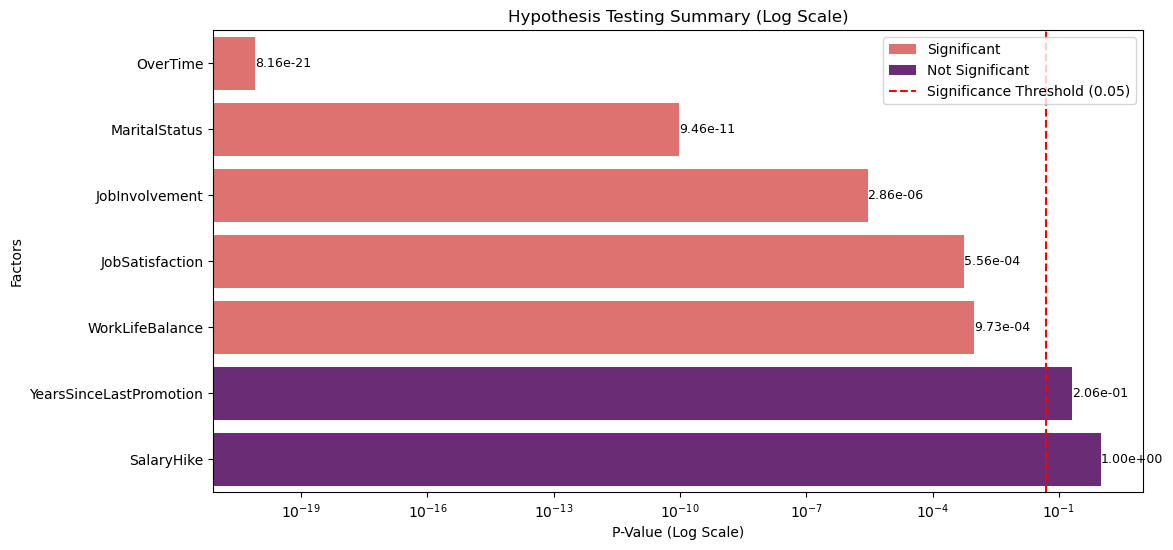

In [335]:
hypothesis_summary = hypothesis_summary.sort_values(
    by="P_Value",
    ascending=True
)
plt.figure(figsize=(12,6))

# Horizontal Bar Plot
ax = sns.barplot(
    x="P_Value",
    y="Factor",
    hue="Result",
    data=hypothesis_summary,
    palette="magma_r"
)

# Log Scale
plt.xscale("log")

# Significance Threshold
plt.axvline(
    x=0.05,
    color="red",
    linestyle="--",
    label="Significance Threshold (0.05)"
)

# Add Labels
for p in ax.patches:  
    width = p.get_width() 
    ax.annotate(  
        f'{width:.2e}',  
        (width, p.get_y() + p.get_height()/2),  
        ha='left',
        va='center',  
        fontsize=9
    )

plt.title("Hypothesis Testing Summary (Log Scale)")
plt.xlabel("P-Value (Log Scale)")
plt.ylabel("Factors")
plt.legend()
plt.show()

# Insight: Hypothesis Testing Summary
The hypothesis testing analysis identified several workforce factors that demonstrate statistically significant relationships with employee attrition.
The strongest statistically significant factors include:
- OverTime,
- JobSatisfaction,
- WorkLifeBalance,
- JobInvolvement,
- and MaritalStatus.

These findings suggest that:
- employee well-being,
- workplace experience,
- engagement,
- workload pressure,
- and workforce lifestyle characteristics
play an important role in influencing employee retention behavior.

Among all tested variables, OverTime demonstrated one of the strongest statistical relationships with attrition, indicating that workload pressure and work-life imbalance may significantly contribute to employee turnover.

In contrast, variables such as:
- SalaryHike,
- and YearsSinceLastPromotion

did not demonstrate statistically significant relationships with attrition within the analyzed dataset.
This suggests that compensation growth and promotion timing alone may not strongly influence employee turnover behavior independently.

Overall, the statistical findings indicate that:
- employee experience,
- organizational environment,
- and workload-related factors

appear more influential in workforce retention than compensation-growth factors alone.

# Logistic Regression

In [336]:
model_data = employee_job.merge(
    employee_performance,
    on="Emp_ID",
    how="inner"
).merge(
    employees_demographic,
    on="Emp_ID",
    how="inner"
).merge(
    employee_attrition,
    on="Emp_ID",
    how="inner"
).merge(
    employee_salary,
    on="Emp_ID",
    how="inner"
)
model_data.head()

,Emp_ID,Department_x,JobRole,JobLevel,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,...,EducationField,Gender,MaritalStatus,Attrition,OverTime,BusinessTravel,MonthlyIncome,HourlyRate,PercentSalaryHike,StockOptionLevel
0,1,Sales,Sales Executive,2,3,3,2,4,1,1,...,Life Sciences,Female,Single,Yes,Yes,Travel_Rarely,5993,94,11,0
1,2,Research & Development,Research Scientist,2,2,4,3,2,4,3,...,Life Sciences,Male,Married,No,No,Travel_Frequently,5130,61,23,1
2,4,Research & Development,Laboratory Technician,1,2,3,4,3,2,3,...,Other,Male,Single,Yes,Yes,Travel_Rarely,2090,92,15,0
3,5,Research & Development,Research Scientist,1,3,3,4,3,3,3,...,Life Sciences,Female,Married,No,Yes,Travel_Frequently,2909,56,11,0
4,7,Research & Development,Laboratory Technician,1,3,3,1,2,4,3,...,Medical,Male,Married,No,No,Travel_Rarely,3468,40,12,1


In [337]:
features = [

    "OverTime",
    "JobSatisfaction",
    "WorkLifeBalance",
    "JobInvolvement",
    "PercentSalaryHike",
    "MaritalStatus"
]

In [338]:
# Encoding Attrition
model_data["Attrition"] = model_data["Attrition"].map({
    "Yes" : 1,
    "No" : 0
})
# Encoding OverTime
model_data["OverTime"] = model_data["OverTime"].map({
    "Yes" : 1,
    "No" : 0
})

In [339]:
model_data = pd.get_dummies(
    model_data,
    columns=["MaritalStatus"],
    drop_first=True
)
model_data.head()

,Emp_ID,Department_x,JobRole,JobLevel,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,...,Gender,Attrition,OverTime,BusinessTravel,MonthlyIncome,HourlyRate,PercentSalaryHike,StockOptionLevel,MaritalStatus_Married,MaritalStatus_Single
0,1,Sales,Sales Executive,2,3,3,2,4,1,1,...,Female,1,1,Travel_Rarely,5993,94,11,0,False,True
1,2,Research & Development,Research Scientist,2,2,4,3,2,4,3,...,Male,0,0,Travel_Frequently,5130,61,23,1,True,False
2,4,Research & Development,Laboratory Technician,1,2,3,4,3,2,3,...,Male,1,1,Travel_Rarely,2090,92,15,0,False,True
3,5,Research & Development,Research Scientist,1,3,3,4,3,3,3,...,Female,0,1,Travel_Frequently,2909,56,11,0,True,False
4,7,Research & Development,Laboratory Technician,1,3,3,1,2,4,3,...,Male,0,0,Travel_Rarely,3468,40,12,1,True,False


In [340]:
X = model_data[
    [
        "OverTime",
        "JobSatisfaction",
        "WorkLifeBalance",
        "JobInvolvement",
        "PercentSalaryHike",
        "MaritalStatus_Married",
        "MaritalStatus_Single"
    ]
]
y = model_data["Attrition"]

In [341]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,                                                   
    y,
    test_size=0.2,
    random_state=42
)

In [342]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(
    X_train,
    y_train
)

LogisticRegression()

In [343]:
y_pred = model.predict(X_test)

In [344]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(
    y_test,
    y_pred
)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.8605442176870748


# Logistic Regression Model Performance
The Logistic Regression model achieved an accuracy of approximately 86%.
This indicates that the model is capable of correctly predicting employee attrition behavior for a majority of employees within the dataset.
The predictive performance suggests that workforce factors such as:
- overtime participation,
- job satisfaction,
- work-life balance,
- job involvement,
- compensation growth,
- and marital status

collectively demonstrate meaningful influence in predicting employee turnover behavior.

In [345]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    y_test,
    y_pred
)
cm

array([[247,   8],
       [ 33,   6]])

| Result Type    | Meaning                              | Count |
| -------------- | ------------------------------------ | ----- |
| True Negative  | Correctly predicted stayed employees | 247   |
| False Positive | Predicted leave but actually stayed  | 8     |
| False Negative | Predicted stay but actually left     | 33    |
| True Positive  | Correctly predicted attrition        | 6     |


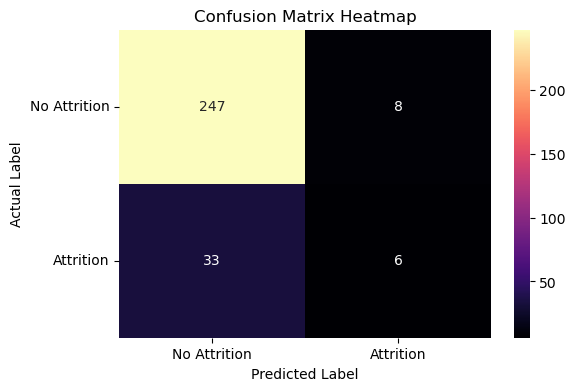

In [346]:
# Confusion Matrix Heatmap

plt.figure(figsize=(6,4))
sns.heatmap(  
    cm,   
    annot=True,  
    fmt="d",
    cmap="magma", 
    cbar=True
)

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks( 
    [0.5, 1.5], 
    ["No Attrition", "Attrition"]
)
plt.yticks(  
    [0.5, 1.5],  
    ["No Attrition", "Attrition"],  
    rotation=0
)
plt.show()

# Confusion Matrix Heatmap Interpretation
The confusion matrix heatmap visualizes the prediction performance of the Logistic Regression model.
The model correctly predicted:
- `247` employees who stayed in the organization,
- and `6` employees who left the organization.

However:
- `8` employees were incorrectly predicted as attrition despite remaining in the organization,
- and `33` employees who actually left were predicted as staying employees.
The heatmap indicates that the model performs strongly in identifying employees who remain within the organization.
However, the model demonstrates weaker performance in predicting attrition cases, as reflected by the higher number of false negatives.
This behavior may result from class imbalance within the dataset, where non-attrition employees significantly outnumber attrition employees.

# Final Project Conclusion

The HR Analytics project successfully analyzed workforce behavior, employee retention patterns, and organizational attrition drivers using descriptive analytics, statistical hypothesis testing, and predictive modeling techniques.

The analysis identified several statistically significant workforce factors associated with employee attrition, including:
- overtime participation,
- work-life balance,
- job satisfaction,
- job involvement,
- and marital status.

The findings suggest that:
- employee well-being,
- workplace engagement,
- organizational experience,
- and workload-related pressure

play an important role in influencing workforce retention behavior.

In contrast, compensation-growth variables such as:
- salary hike percentage,
- and years since last promotion

did not demonstrate statistically significant independent relationships with attrition within the analyzed dataset.

The Logistic Regression model achieved approximately `86%` prediction accuracy, demonstrating strong capability in predicting employee retention behavior.

Overall, the project demonstrates how data analytics, statistical validation, and machine learning techniques can support workforce decision-making and employee retention strategies within organizations.